## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
MONTH = 7

In [3]:
years = range(2024, 2026)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2024 | (8844, 102)
Year: 2025 | (5159, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2024,1,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,9.364194,10.927097,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,4.883174,10.569020,14.188456,148.323639,151.378399,151.378399,-1.450,16.55,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN
1,0,2024-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2024,2,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,9.434138,11.307586,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,7.137716,114.943450,195.384068,207.398673,358.372156,206.993757,4.910,15.91,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN
2,0,2024-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2024,3,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,9.587419,12.825161,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,0.941541,4.710541,9.336516,13.069732,387.559926,29.187771,5.270,24.19,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN
3,0,2024-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2024,4,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.883333,17.182333,12.490000,13.181034,16.062903,21.481333,9.364194,9.434138,9.587419,12.883333,10.927097,11.307586,12.825161,17.182333,1.022162,0.302366,28.825284,30.664851,418.224778,30.664851,6.830,28.13,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,33439.0,168448.0,4

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

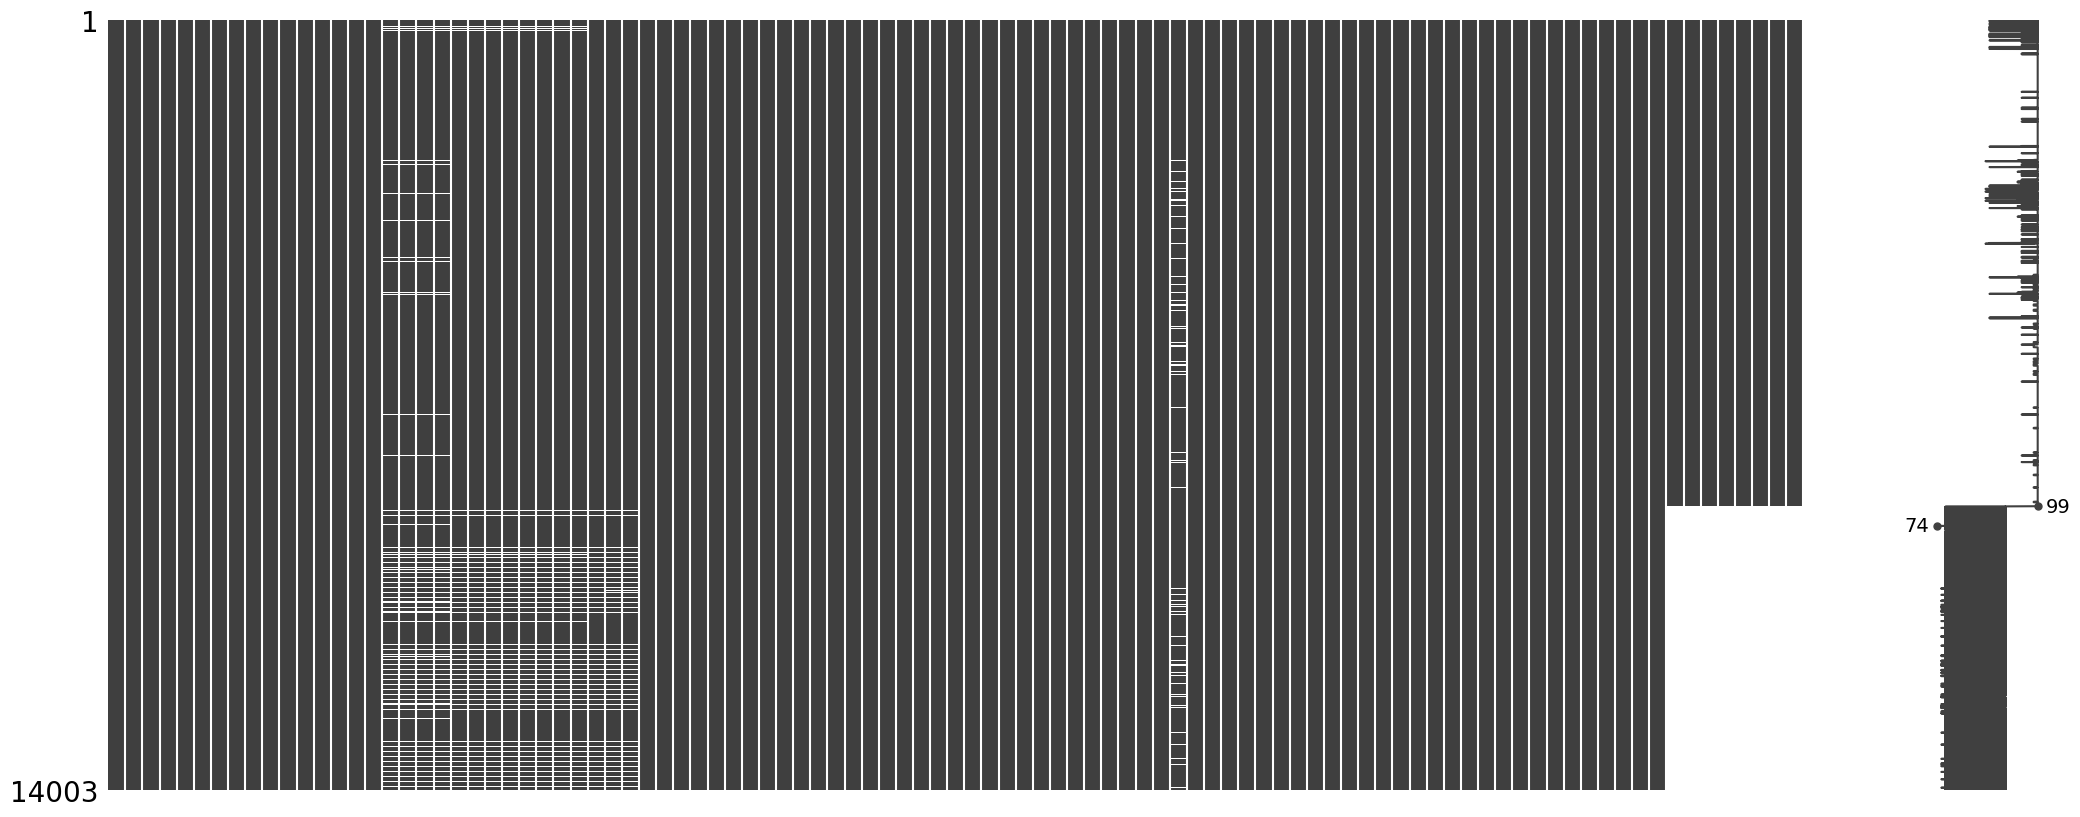

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,7.0342
17,ndmi,7.0342
18,ndwi,7.0342
19,ndbi,7.0342
20,ndvi_mean,5.5702
...,...,...
97,F_Y_GE65,36.8421
98,F_TOTAL,36.8421
99,MIO_EUR,100.0000
100,L_TOTAL,100.0000


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_ID', 'rainfall_acc', 'NUTS1_NAME']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2024-01,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,1,2024,0.453702,0.162273,-0.373644,-0.162273,0.417976,0.173836,-0.328185,-0.173836,0.044335,0.044013,0.054985,0.044013,12.490000,12.490000,13.181034,16.062903,21.481333,9.364194,9.364194,9.434138,9.587419,12.883333,10.927097,10.927097,11.307586,12.825161,17.182333,-1.450,16.55,4.883174,10.569020,14.188456,148.323639,151.378399,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
1,2024-02,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,2,2024,0.459899,0.156819,-0.383792,-0.156819,0.433261,0.163800,-0.360059,-0.163800,0.059659,0.041815,0.063084,0.041815,13.181034,12.490000,13.181034,16.062903,21.481333,9.434138,9.364194,9.434138,9.587419,12.883333,11.307586,10.927097,11.307586,12.825161,17.182333,4.910,15.91,7.137716,114.943450,195.384068,207.398673,358.372156,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
2,2024-03,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,3,2024,0.476548,0.151681,-0.419050,-0.151681,0.461091,0.144800,-0.410378,-0.144800,0.034096,0.020828,0.027412,0.020828,16.062903,12.490000,13.181034,16.062903,21.481333,9.587419,9.364194,9.434138,9.587419,12.883333,12.825161,10.927097,11.307586,12.825161,17.182333,5.270,24.19,0.941541,4.710541,9.336516,13.069732,387.559926,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
3,2024-04,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,4,2024,0.456022,0.120288,-0.422576,-0.120288,0.428696,0.110163,-0.399211,-0.110163,0.042036,0.025916,0.026007,0.025916,21.481333,12.490000,13.181034,16.062903,21.481333,12.883333,9.364194,9.434138,9.587419,12.883333,17.182333,10.927097,11.307586,12.825161,17.182333,6.830,28.13,1.022162,0.302366,28.825284,30.664851,418.224778,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,85,20,85.0,20,85,9,9,4,2,2,2,0,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
4,2024-05,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,2

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
months = range(1,MONTH+1)

In [19]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2025 | Month: 1
Year: 2025 | Month: 2
Year: 2025 | Month: 3
Year: 2025 | Month: 4
Year: 2025 | Month: 5
Year: 2025 | Month: 6
Year: 2025 | Month: 7


In [20]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE


In [21]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2025)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL30,EL307,κυθηρων,2025,1,22.92536,36.22923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.470800,14.32871,10.381429,15.805484,18.750741,9.282500,9.09129,5.849286,9.367419,11.136154,10.307083,11.71,8.115357,12.586452,14.943447,6.07,15.75,0.897667,15.610000,22.349999,26.929999,87.469998,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
737,0,EL30,EL307,κυθηρων,2025,2,22.92536,36.22923,0.432013,0.083407,-0.381338,-0.083407,0.389504,0.115818,-0.294944,-0.115818,0.061180,0.040032,0.066543,0.040032,14.328710,14.32871,10.381429,15.805484,18.750741,9.091290,9.09129,5.849286,9.367419,11.136154,11.710000,11.71,8.115357,12.586452,14.943447,5.01,15.71,2.821613,0.890000,28.569999,87.469998,357.649991,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
1474,0,EL30,EL307,κυθηρων,2025,3,22.92536,36.22923,0.403956,0.073849,-0.363431,-0.073849,0.389734,0.119886,-0.288719,-0.119886,0.050255,0.031638,0.054882,0.031638,10.381429,14.32871,10.381429,15.805484,18.750741,5.849286,9.09129,5.849286,9.367419,11.136154,8.115357,11.71,8.115357,12.586452,14.943447,2.45,15.09,9.649285,120.549997,239.829994,270.709993,391.769990,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
2211,0,EL30,EL307,κυθηρων,2025,4,22.92536,36.22923,0.419150,0.080605,-0.377346,-0.080605,0.411708,0.119997,-0.346138,-0.119997,0.050678,0.039874,0.067993,0.039874,15.805484,14.32871,10.381429,15.805484,18.750741,9.367419,9.09129,5.849286,9.367419,11.136154,12.586452,11.71,8.115357,12.586452,14.943447,5.51,21.93,1.100645,8.750000,21.270000,33.899999,416.129989,18.75,15.833333,40.598291,764.109702,38.0,-1.0,39.0,10.5,25.333333,28.166667,9.166667,625.0,206.0,0.0,128.614366,386.0,8.0,29.0,383.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,33439.0,168448.0,48898.0,250785.0,31622.0,167505.0,64826.0,263953.0,NaN,NaN,NaN,2,1,1
2948,0,EL30,EL307,κυθηρων,2025,5,22.92536,36.22923,0.467388,0.108242,-0.423855,-0.108242,0.419608,0.112332,-0.375822,-0.112332,0.037769,0.032868,0.039894,0.032868,18.750741,14.32871,10.381429,15.805484,18.750741,11.136154,9.09129,5.849286,9.367419,11.136154,15.036923,11.71,8.115357,12.586452,14.943447,5.89,22.95,0.812000,5.160000,7.050000,24.359999,418.339989,18.75,15.833333,40.598291,764.109702,38.0,-

<Axes: >

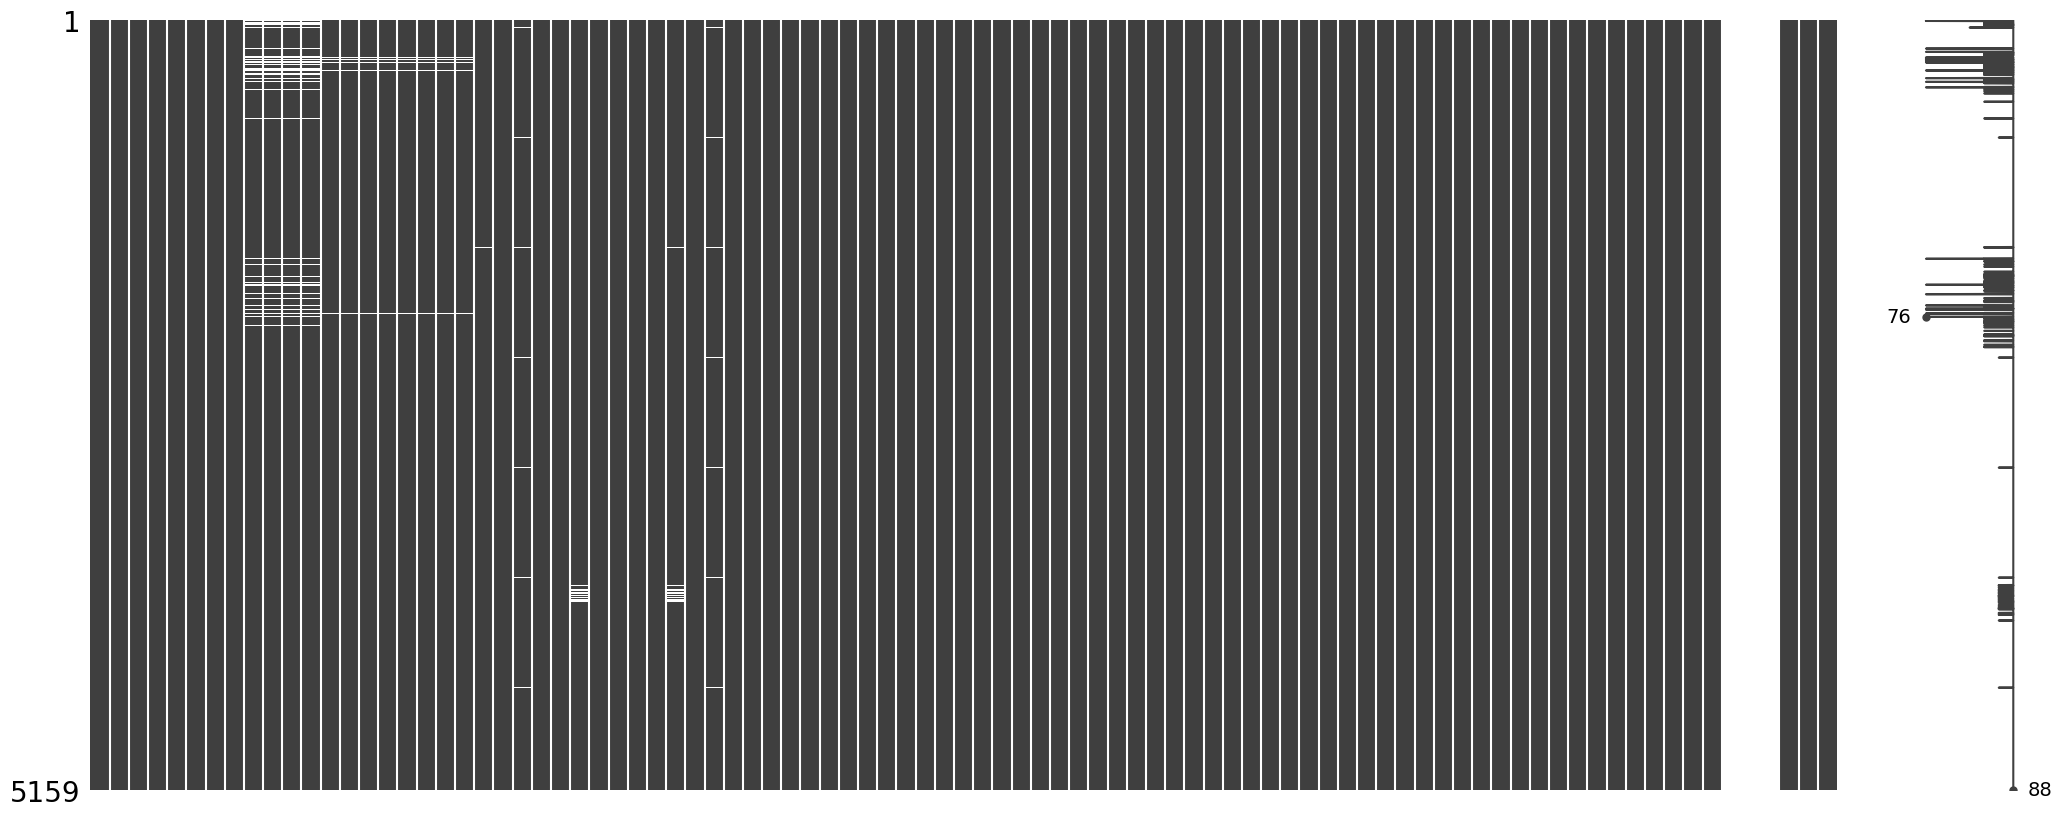

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,4.1481
9,ndmi,4.1481
10,ndwi,4.1481
11,ndbi,4.1481
12,ndvi_mean,0.6590
13,ndmi_mean,0.6590
14,ndwi_mean,0.6590
15,ndbi_mean,0.6590
16,ndvi_std,0.6590
17,ndmi_std,0.6590


In [24]:
# dataset_monthly.cases.sum()

In [25]:
# dataset_operational.cases.sum()

In [26]:
years = dataset_operational.year.unique().tolist()

In [27]:
years

[2025]

In [28]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)